---
numbering: false
---

# 8.3. Gradient Descent

In [Chapter 8.1](01-gradient-vector.ipynb), we learned about the **gradient**, the equivalent of the derivative for **vector-to-scalar** functions. The big takeaway was that $\nabla f(\vec x)$ describes the direction in which $f$ is increasing the quickest, at the point $\vec x$.

At the end of Chapter 8.1, we **minimized**

$$R_\text{sq}(\vec w) = \frac{1}{n} \lVert \vec y - X \vec w \rVert^2$$

by computing its gradient, setting it to 0, and solving for $\vec w^*$, which gave us another way of deriving the normal equations.

So far, most of the empirical risk functions that we've minimized had **closed-form solutions** – that is, formulas for the optimal parameters $w_0^*, w_1^*, ...$ that we could find by hand using algebra.
 
\begin{align*}
R_\text{sq}(w)                  &= \frac{1}{n} \sum_{i = 1}^n (y_i - w)^2                   &&\implies\quad w^* = \bar{y} \\
R_\text{sq}(w_0, w_1)           &= \frac{1}{n} \sum_{i = 1}^n (y_i - (w_0 + w_1 x_i))^2    &&\implies\quad w_1^* = r \frac{\sigma_y}{\sigma_x},\quad w_0^* = \bar{y} - w_1^* \bar{x} \\
R_\text{sq}(\vec w)             &= \frac{1}{n} \lVert \vec y - X \vec w \rVert^2           &&\implies\quad \vec{w}^* = (X^T X)^{-1} X^T \vec{y}
\end{align*}

But, soon we'll encounter combinations of models and loss functions whose empirical risk functions that have _some_ global minimum, but that global minimum isn't described by a formula that we can write by hand. There was an example of such an empirical risk function from a previous homework; see if you can remember what it was!

As another example, the **logistic regression** model, used for predicting the probability of a binary event (e.g. whether or not a patient has a disease) makes predictions using

$$h(\vec x_i) = P(y_i = 1 \mid \vec x_i) = \frac{1}{1 + e^{- \vec w \cdot \text{Aug}(\vec x_i)}}$$

Logistic regression typically uses the **cross-entropy** loss function,

$$L_\text{ce}(y_i, h(\vec x_i)) = - \left( y_i \log h(\vec x_i) + (1 - y_i) \log (1 - h(\vec x_i)) \right)$$

resulting in the empirical risk function

$$R_\text{ce}(\vec w) = - \frac{1}{n} \sum_{i = 1}^n \left( y_i \log \left( \frac{1}{1 + e^{- \vec w \cdot \text{Aug}(\vec x_i)}} \right) + (1 - y_i) \log \left( 1 - \frac{1}{1 + e^{- \vec w \cdot \text{Aug}(\vec x_i)}} \right) \right)$$

(What a mess!)

$R_\text{ce}(\vec w)$ is a vector-to-scalar function, and it has a gradient, $\nabla R_\text{ce}(\vec w)$. The issue is that the solutions to $\nabla R_\text{ce}(\vec w) = \vec 0$ can't be found by hand. But, $\nabla R_\text{ce}(\vec w)$ still means **something** – and we can use it to estimate $\vec w^*$ without solving for it explicitly.

Throughout this section, keep the following thought exercise in mind:

> Suppose you're at the top of a mountain 🏔️ and **need to get to the bottom**. And, perhaps it's really cloudy ☁️, meaning you can only see a few feet around you. **How** would you get to the bottom?

---

## What do Derivatives Tell Us?

Let's start with a simpler, scalar-to-scalar example. Suppose we'd like to **minimize** the function

$$f(x) = 5x^4 - x^3 - 5x^2 + 2x - 9$$

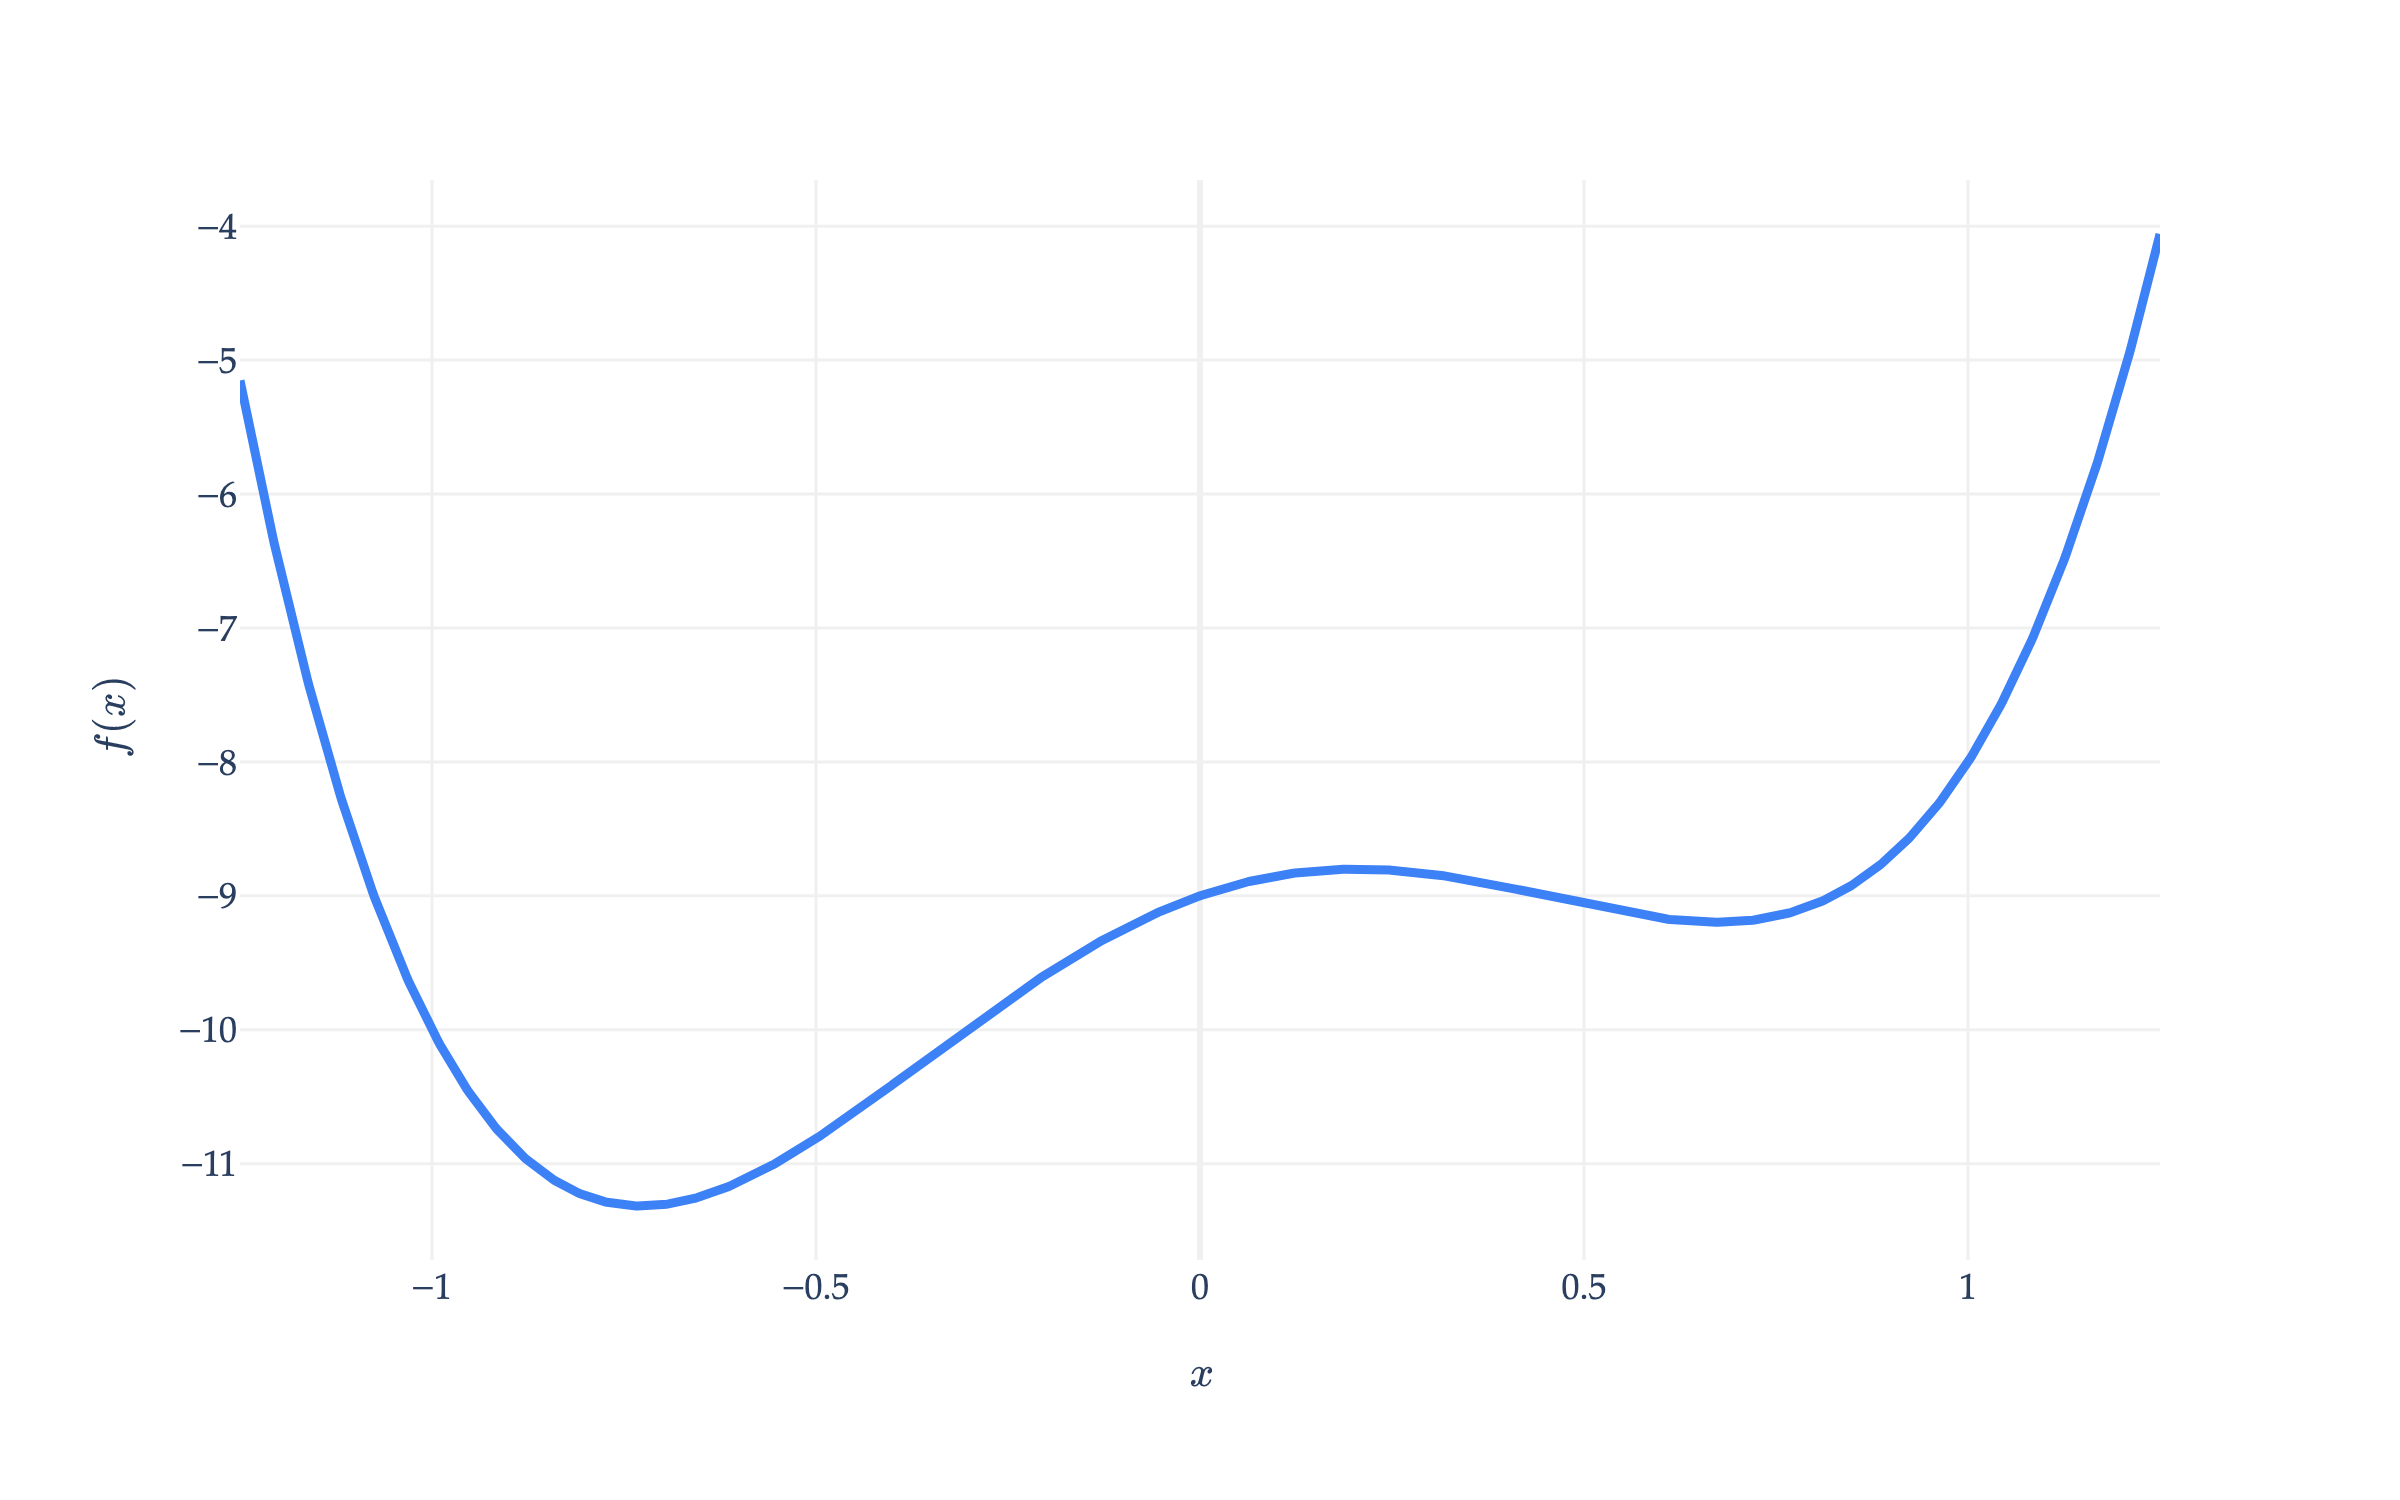

In [1]:
import numpy as np
import plotly.express as px

def f(x):
    return 5 * (x**4) - (x**3) - 5 * (x**2) + 2 * x - 9

def df(x):
    return 20 * (x**3) - 3 * (x**2) - 10 * x + 2

def draw_f():
    xs = np.linspace(-1.25, 1.25, 1000)
    ys = f(xs)
    fig = px.line(
        x=xs, 
        y=ys,
        line_shape="linear"
    )
    # Update the line width to 5
    fig.update_traces(line=dict(width=3, color='#3d81f6'))
    fig.update_layout(
        xaxis_title='$x$', 
        yaxis_title='$f(x)$', 
        width=800, 
        height=500,
        font=dict(family="Palatino, serif"),  # Palatino font
        plot_bgcolor="white",
        paper_bgcolor="white",
    )
    fig.update_xaxes(tickcolor='#f0f0f0', gridcolor='#f0f0f0', zerolinecolor='#f0f0f0')
    fig.update_yaxes(tickcolor='#f0f0f0', gridcolor='#f0f0f0', zerolinecolor='#f0f0f0')
    return fig

fig = draw_f()
fig.show(renderer='png', scale=3)

There are some not-so-elegant techniques for minimizing $f$. For instance, we _could_ evaluate $f$ at dozens (or hundreds) of possible $x$'s, and pick the one that had the smallest output. But, that's an inefficient way to go about things, especially as the number of input variables (i.e. the $d$ in $\vec x \in \mathbb{R}^d$) increases.

Instead, we'll use the fact that $f$ is **differentiable**. Its derivative is

$$\frac{\text{d}f}{\text{d}x}(x) = 20x^3 - 3x^2 - 10x + 2$$

Typically, to minimize $f$, we'd
1. Find $\frac{\text{d}f}{\text{d}x}(x)$.
1. Solve for the input $x^*$ such that $\frac{\text{d}f}{\text{d}x}(x^*) = 0$.

But, $\frac{\text{d}f}{\text{d}x}(x) = 0$ is a cubic equation, which is difficult to solve by hand (there is actually a "cubic formula", the same way there's a "quadratic formula", but higher-degree polynomials don't have similar formulas). What can we do with its derivative?

**The key idea is that we'll take an iterative approach**. Suppose we start with an initial guess for $x^*$, say, $x^{(0)}$.

**Case 1**: If the derivative at $x^{(0)}$ is positive ⬆️, then $f$ is increasing at $x^{(0)}$, which means to decrease $f$, we should move to the **left** of $x^{(0)}$.

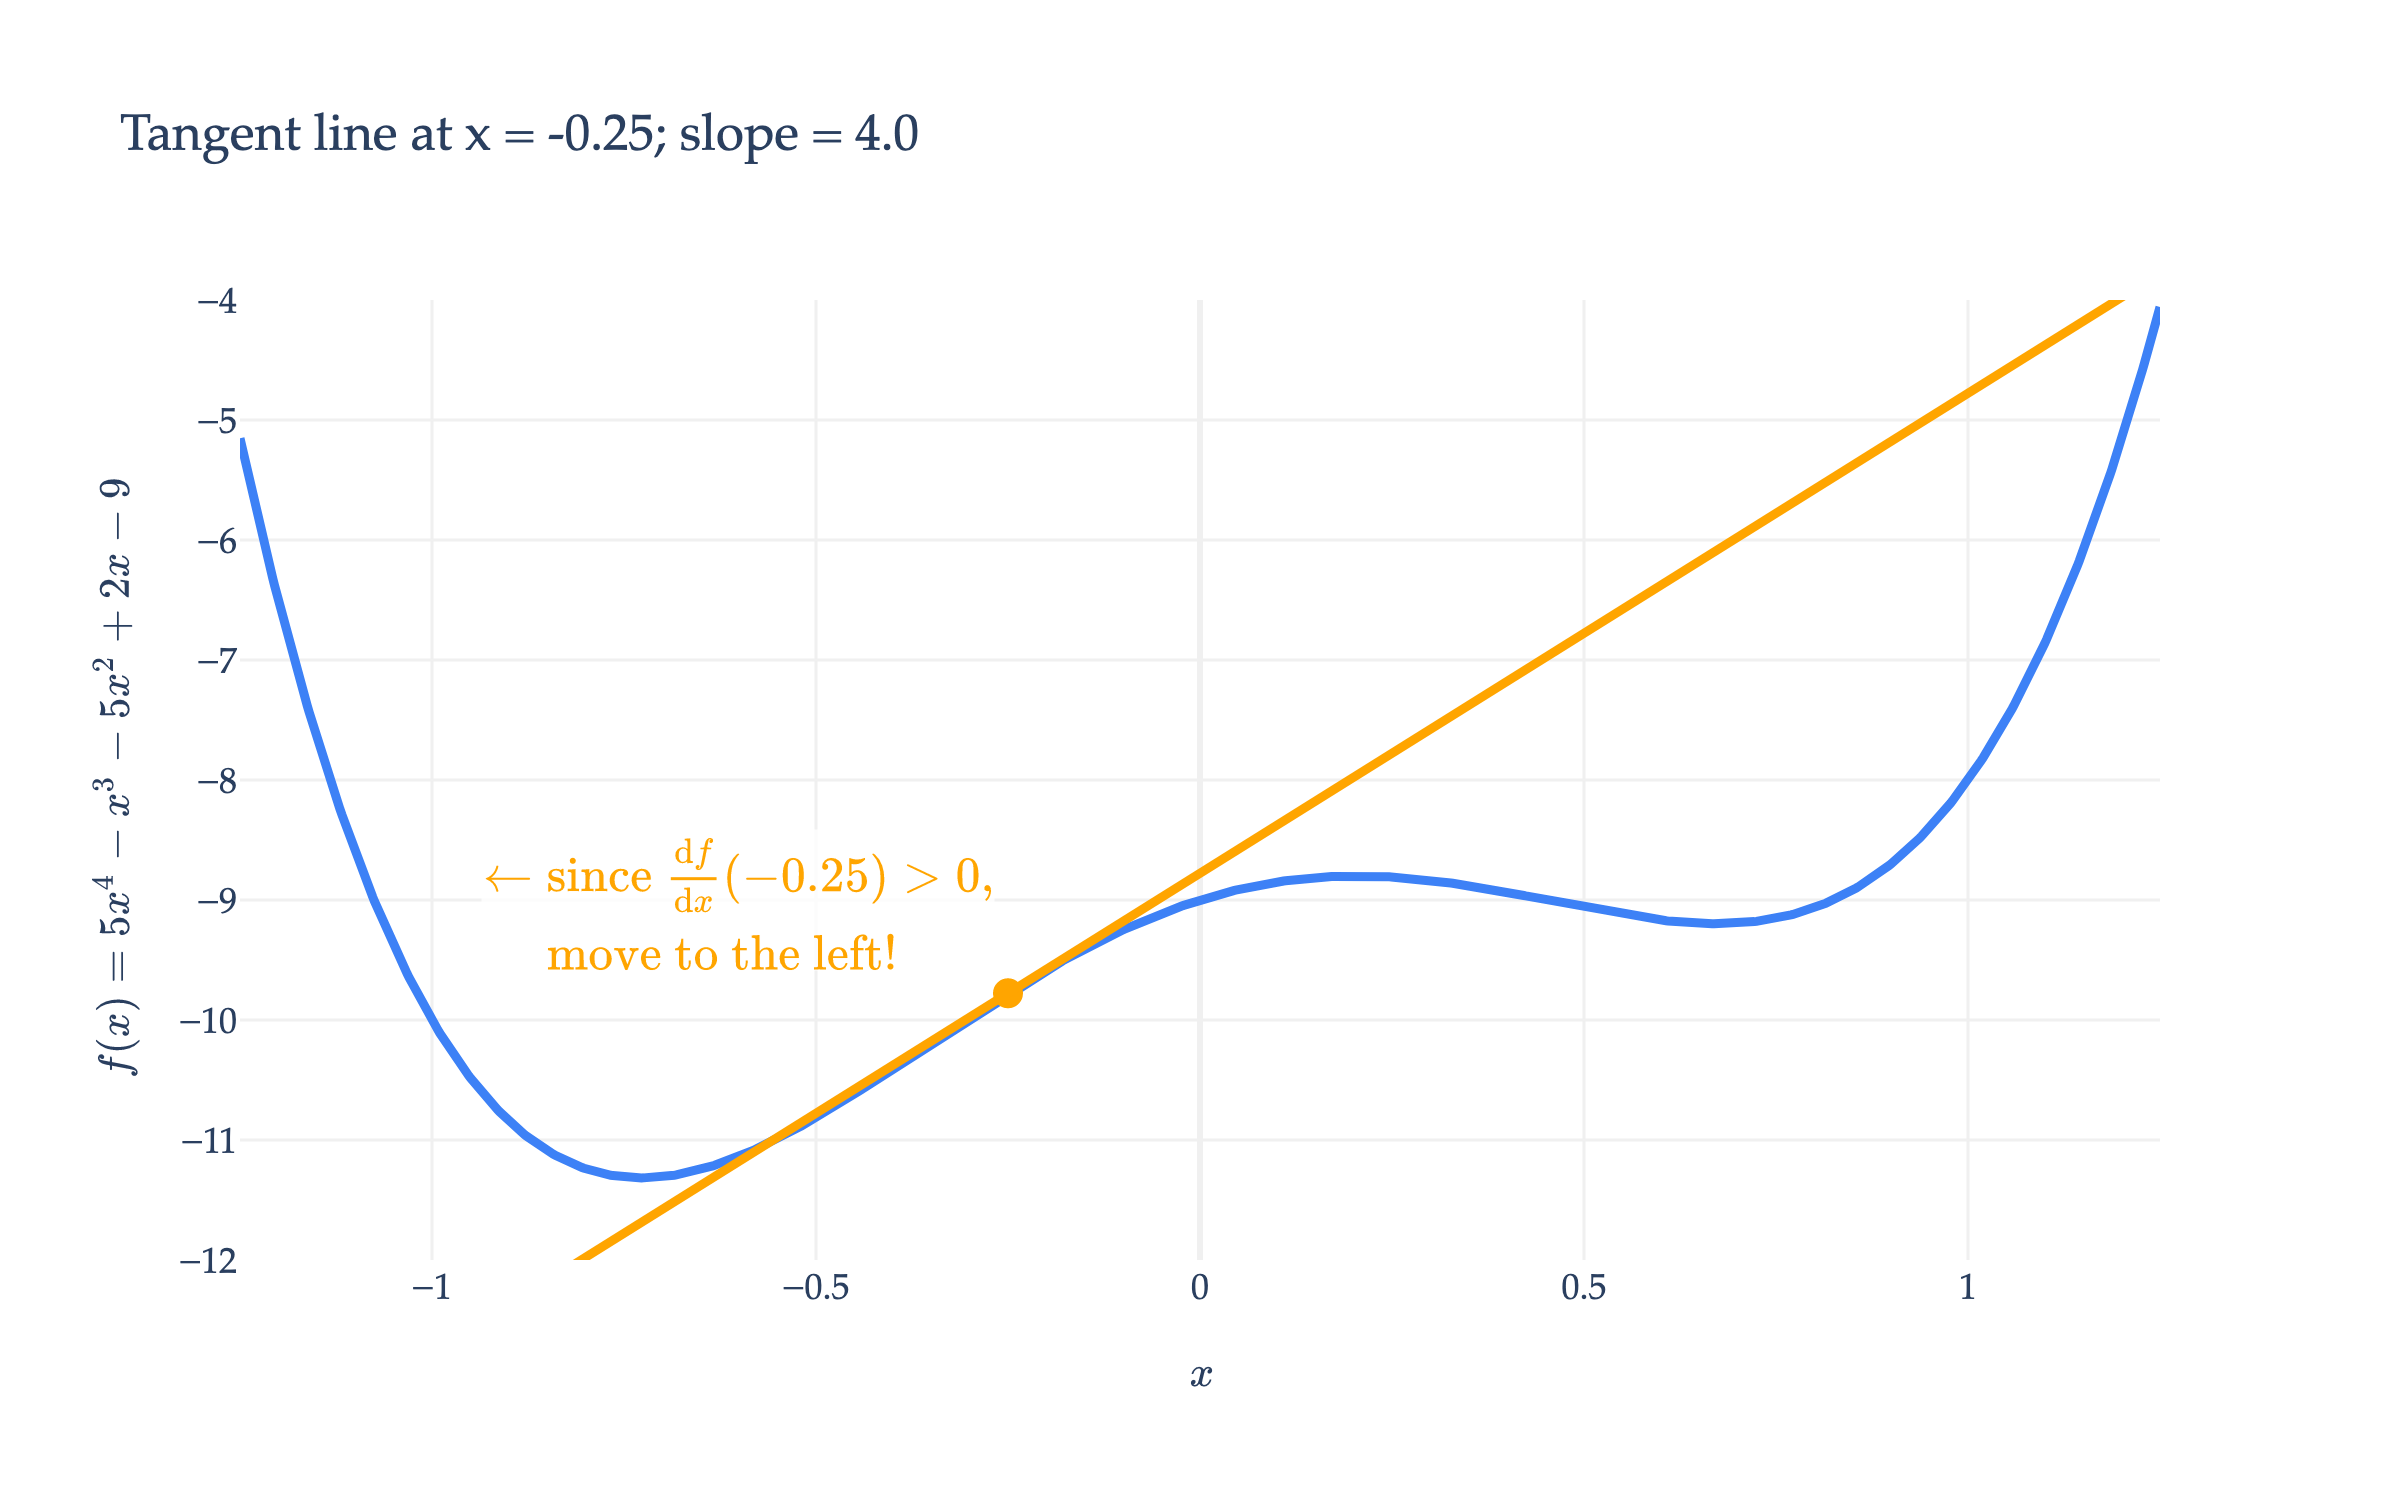

In [2]:
import plotly.graph_objects as go

def create_tangent_line(f, df, x):
    slope = df(x)
    intercept = f(x) - slope * x
    return lambda x: intercept + slope * x
    
def show_tangent(x0):
    fig = draw_f()
    tan_fn = create_tangent_line(f, df, x0)
    fig2 = go.Figure(fig.data)
    fig2.add_trace(go.Scatter(x=[x0], y=[f(x0)], marker={'color': 'orange', 'size': 10}, showlegend=False))
    fig2.add_trace(go.Scatter(x=[-5, 5], y=[tan_fn(-5), tan_fn(5)], line={'color': 'orange', 'width': 3}, name='Tangent Line'))
    fig2.update_xaxes(range=[-1.25, 1.25], tickcolor='#f0f0f0', gridcolor='#f0f0f0', zerolinecolor='#f0f0f0')
    fig2.update_yaxes(range=[-12, -4], tickcolor='#f0f0f0', gridcolor='#f0f0f0', zerolinecolor='#f0f0f0')
    fig2.update_layout(
        title=f'Tangent line at x = {round(x0, 2)}; slope = {round(df(x0), 5)}',
        xaxis_title=r'$x$',
        yaxis_title=r'$f(x) = 5x^4 - x^3 - 5x^2 + 2x - 9$',
        showlegend=False,
        font=dict(family="Palatino, serif"),  # Set font to Palatino
        width=800,
        height=500,
        plot_bgcolor="white",
        paper_bgcolor="white"
    )
    return fig2

fig = show_tangent(-0.25)
fig.add_annotation(
    x=-0.6, y=-9,
    text=r"$\leftarrow \text{since } \frac{\text{d}f}{\text{d}x}(-0.25) > 0,\, \\ \:\:\:\:\: \text{move to the left!}$",
    font=dict(size=16, family="Palatino, serif", color="orange"),
    align="center",
    bgcolor="rgba(255,255,255,0.8)",
    # bordercolor="orange",
    showarrow=False
)
fig.show(renderer='png', scale=3)

**Case 2**: If the derivative at $x^{(0)}$ is negative 📉, then $f$ is decreasing at $x^{(0)}$, which means to decrease $f$, we should move to the **right** of $x^{(0)}$ ➡️.

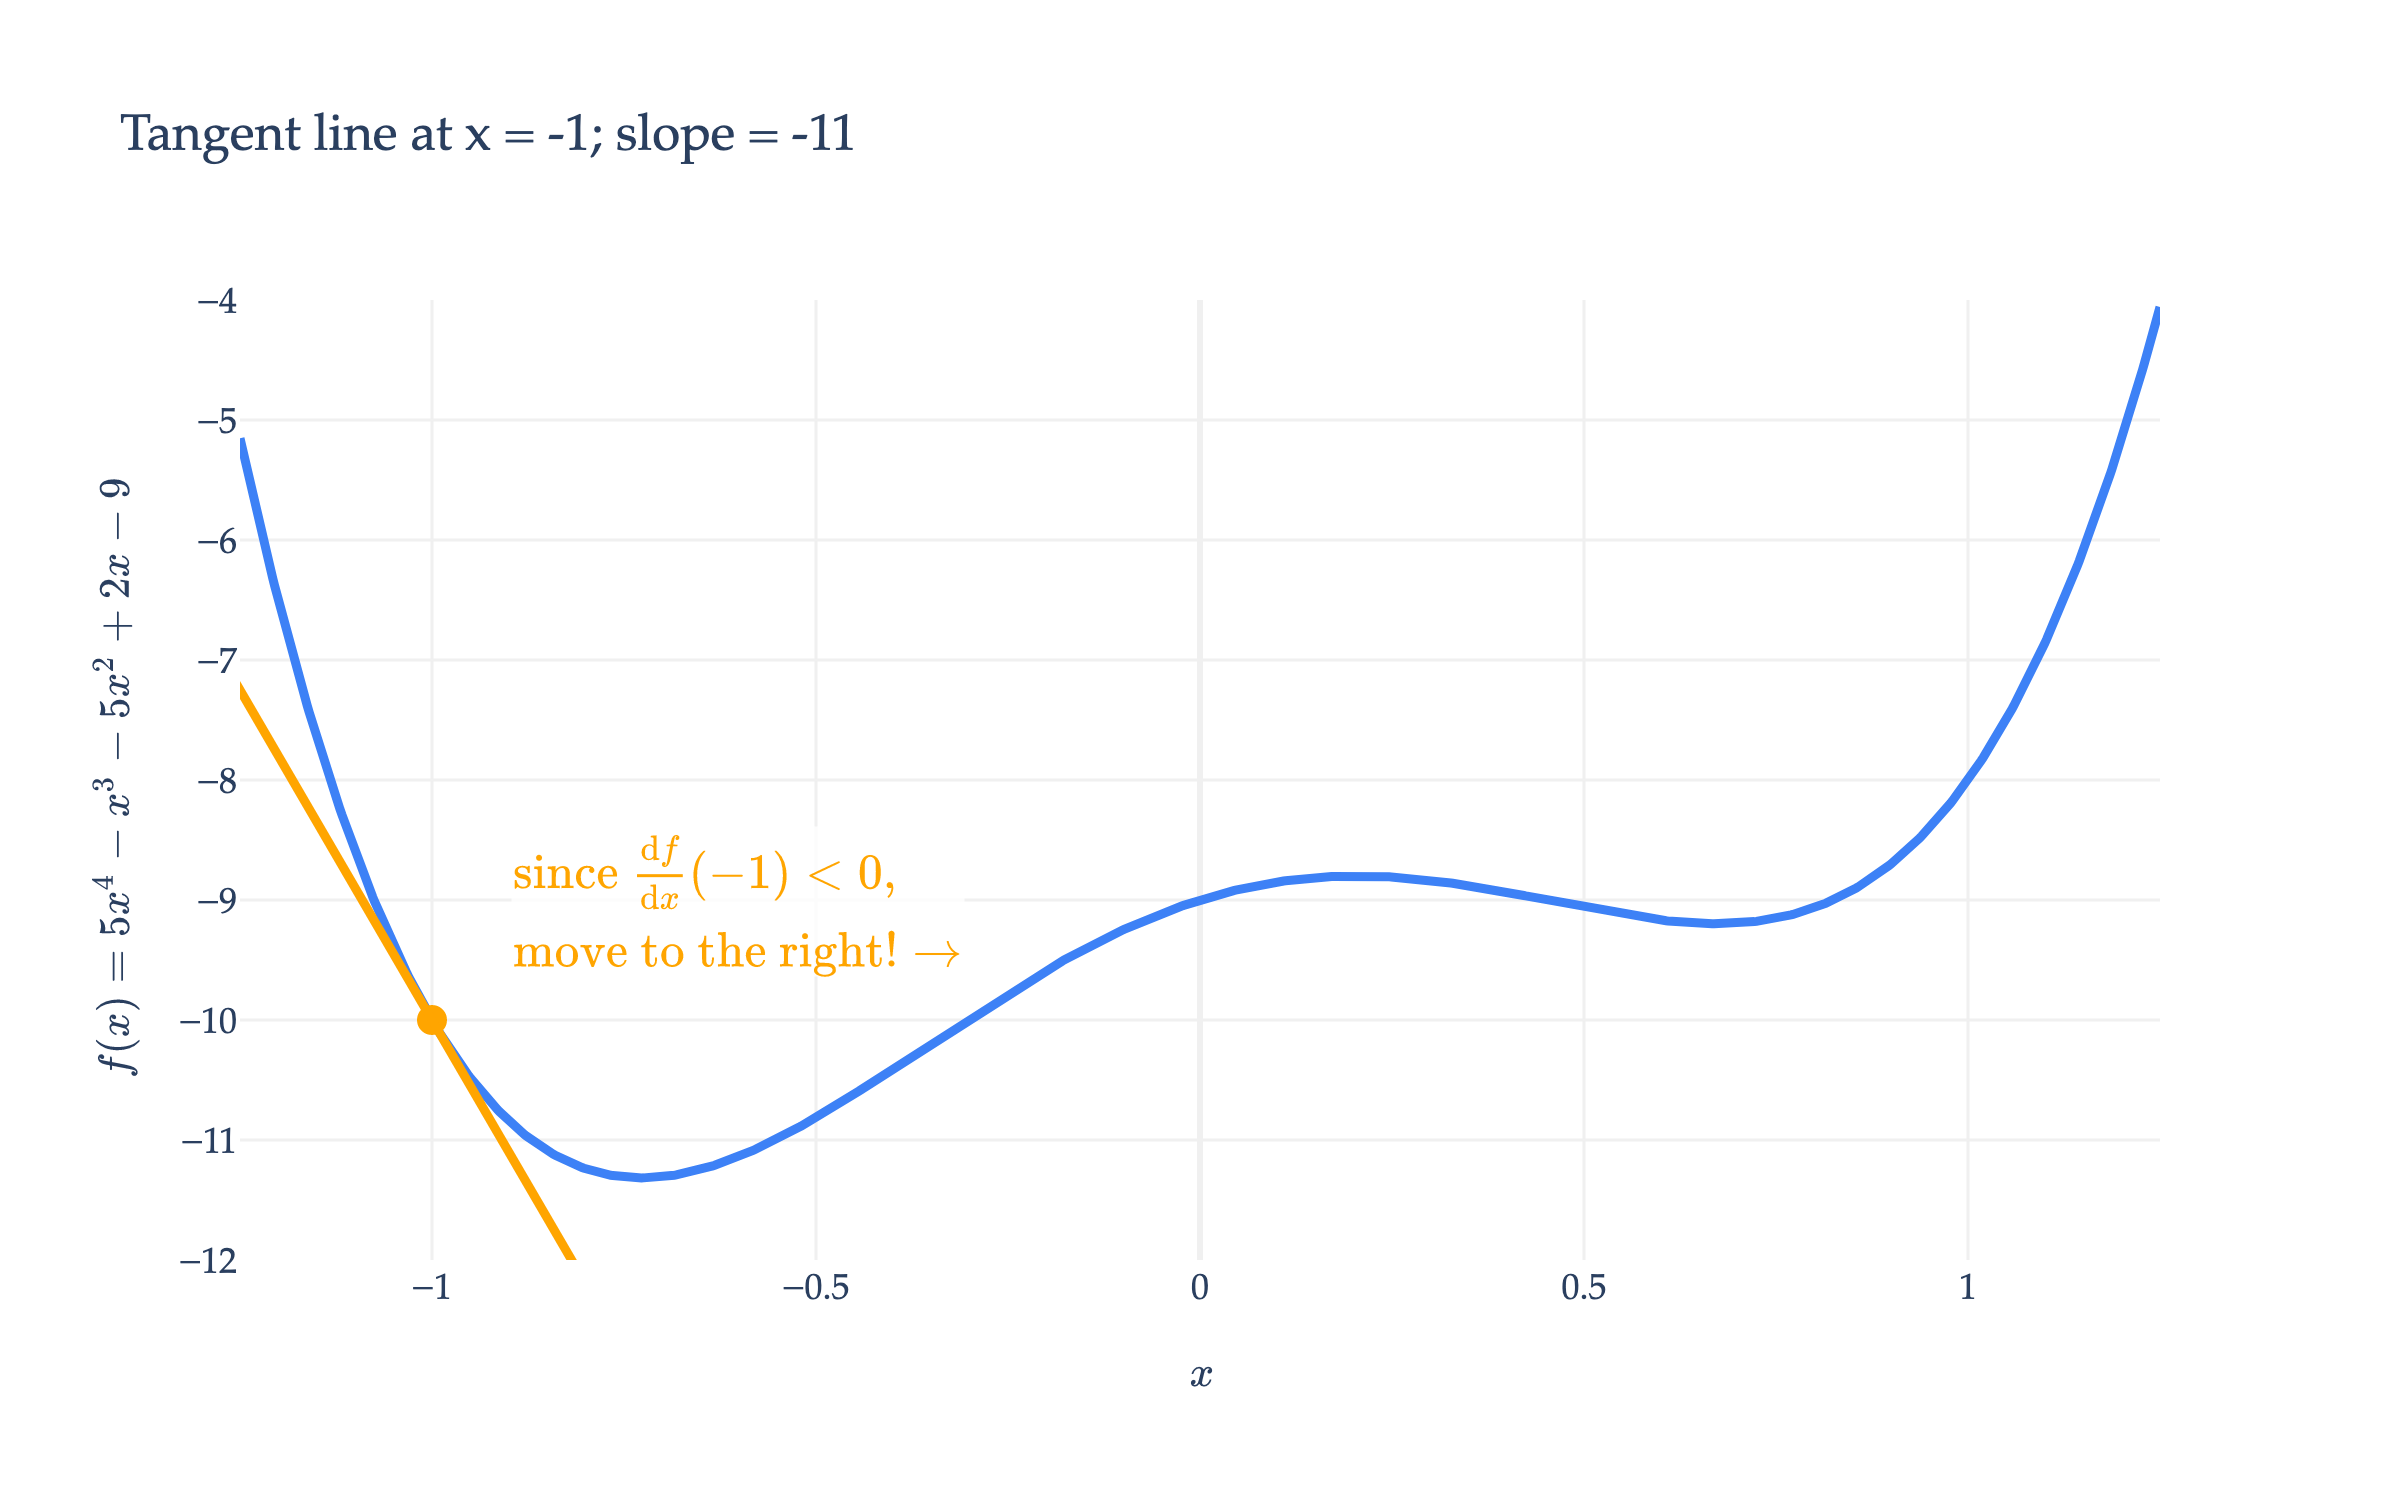

In [3]:
fig = show_tangent(-1)
fig.add_annotation(
    x=-0.6, y=-9,
    text=r"$\text{since } \frac{\text{d}f}{\text{d}x}(-1) < 0,\, \\ \text{move to the right!} \rightarrow$",
    font=dict(size=16, family="Palatino, serif", color="orange"),
    align="center",
    bgcolor="rgba(255,255,255,0.8)",
    # bordercolor="orange",
    showarrow=False
)
fig.show(renderer='png', scale=3)

Remember that at a minimum (or maximum), the derivative is 0 (if it exists), and gradually approaches 0, at least for the types of functions we'll consider. So, if the derivative at our current guess is large, we must be far away from a minimum, and should take a larger step than if the derivative is small (which must mean we're close to the minimum already).

This intuition is the basic idea behind **gradient descent**. The fact that "gradient" is in the name implies that it's typically used for minimizing vector-to-scalar functions $f: \mathbb{R}^d \rightarrow \mathbb{R}$, which we will use it for shortly. I just figured a scalar-to-scalar example would help build intuition.

---

## Gradient Descent

:::{note} Definition: Gradient Descent

Suppose $f: \mathbb{R}^d \rightarrow \mathbb{R}$ is a **differentiable** vector-to-scalar function, meaning that all of its partial derivatives are defined everywhere.

To find $\vec x^*$, the minimizer of $f$:

1. Choose a positive number, $\mathbf{\alpha}$. This number is called the **learning rate**, or **step size**.
1. Choose an **initial guess** for the minimizer, $\vec x^{(0)}$.
1. Then, repeatedly update the guess using the **update rule**:
    $$\vec x^{(t+1)} = \vec x^{(t)} - \alpha \nabla f(\vec x^{(t)})$$
1. Terminate once the algorithm converges, which happens when the norm of the gradient, $\lVert \nabla f(\vec x^{(t)}) \rVert$, is below some small **tolerance** level, e.g. $0.001$ (since this must mean we're very close to a minimum).
:::

Gradient descent is a **numerical method** for finding the input to a function $f$ that **minimizes** the function. Ultimately, that's what this is about: minimizing functions.

A numerical method is a technique for approximating the solution to a mathematical problem, often by using the computer. Since it only involves first (partial) derivatives, it's called a **first-order method**; numerical methods that use second (partial) derivatives are called **second-order methods**.

**Gradient descent is _the_ workhorse of machine learning**. As I stated earlier, it's used to minimize empirical risk, $R(\vec w)$, in the general case, where it can't be minimized by hand. (In the first few examples we'll see, we'll use gradient descent to minimize arbitrary functions of the form $f(\vec x)$, but in [Chapter 8.4](./04-gradient-descent-erm.ipynb) we'll return to minimizing empirical risk functions specifically.) This is especially true for state-of-the-art models, like neural networks and transformers, which have billions of parameters. So, when you hear about companies spending billions of dollars on training models, they're spending money to run gradient descent on their oceans of data and models with billions of parameters.

### Example Implementation

To get a feel for how it works, let's implement gradient descent ourselves on the scalar-to-scalar function we looked at earlier,

$$f(x) = 5x^4 - x^3 - 5x^2 + 2x - 9, \qquad \frac{\text{d}f}{\text{d}x}(x) = 20x^3 - 3x^2 - 10x + 2$$

For scalar-to-scalar functions, we can replace the gradient with the derivative, and the update rule becomes

$$x^{(t+1)} = x^{(t)} - \alpha \frac{\text{d}f}{\text{d}x}(x^{(t)})$$

Let's start with an initial guess of $x^{(0)} = 0$ and a learning rate of $\mathbf{\alpha} = 0.01$.

In [4]:
def df(x):
    return 20 * (x**3) - 3 * (x**2) - 10 * x + 2

def minimize_f(x0, alpha, tol=0.0001):
    x = x0 # Initial guess
    t = 0 # Iteration counter (just for tracking)

    while np.abs(df(x)) > tol:
        # The core logic is in this one line
        x = x - alpha * df(x)

        # Everything below is for us to track the progress of the algorithm
        t += 1
        if t % 10 == 0:
            print(f't = {t}: x = {x}, df/dx = {df(x)}')
    print(f"Converged in {t} iterations")

minimize_f(x0=0, alpha=0.01)


t = 10: x = -0.3019961066782706, df/dx = 4.195505266352445
t = 20: x = -0.6539833552473451, df/dx = 1.6626527284020556
t = 30: x = -0.7227462183452047, df/dx = 0.10967130332536357
t = 40: x = -0.7267760078170167, df/dx = 0.005439315124045052
t = 50: x = -0.7269745284952817, df/dx = 0.0002654471448240159
Converged in 54 iterations


With our initial guess of $x^{(0)} = 0$ and a learning rate of $\alpha = 0.01$, the algorithm converges to $x^* \approx -0.727$ in 54 iterations.

### Animations

Let's visualize the execution of the algorithm on this $f(x)$, with several different choices of initial guess and learning rate. In each animation, click the "▶️ Start animation" button to see the algorithm in action. (If the algorithm stops somewhere that isn't a minimum, it's because I set them to only show 50 iterations.)

**Initial guess = $0$, step size = $0.01$**

In [5]:
def minimizing_animation(x0, alpha):

    play_button = {'label': '▶️ Start animation', 'method': 'animate', 'args': [None]}

    stop_button = dict(label='⏯️ Stop animation', method='animate', visible = True,
                args=[(), {'frame': {'duration': 0, 'redraw': False}, 'mode': 'next', 'fromcurrent': True}])

    x = x0
    xs = []
    dfxs = []
    for t in range(50):
        xs.append(x)
        dfxs.append(df(x))
        x = x - alpha * df(x)

    fig = draw_f()

    # Extract layout and background from fig to preserve styling
    base_layout = fig.layout

    grad_anim = go.Figure(
        data=[
            fig.data[0], 
            go.Scatter(
                x=[xs[0]], y=[f(xs[0])], 
                marker={'size': 20, 'color': 'orange'}, showlegend=False
            )
        ],
        frames=[
            go.Frame(
                data=[
                    fig.data[0], 
                    go.Scatter(
                        x=[xs[t]], y=[f(xs[t])], 
                        marker={'size': 20, 'color': 'orange'}, showlegend=False
                    )
                ]
            )
            for t in range(50)
        ],
        layout=go.Layout(
            updatemenus=[dict(
                type="buttons",
                buttons=[play_button, stop_button])],
            # title=fr'$\text{{Gradient Descent on }} f(x) = 5x^4 - x^3 - 5x^2 + 2x - 9 \\ \text{{Initial Guess = }} x^{{(0)}} = \mathbf{{{x0}}}; \:\:\:\: \text{{Step Size = }} \alpha = \mathbf{{{alpha}}}$',
            xaxis=base_layout.xaxis,
            yaxis=base_layout.yaxis,
            template=base_layout.template if 'template' in base_layout else None,
            plot_bgcolor=base_layout.plot_bgcolor if 'plot_bgcolor' in base_layout else "#fff",
            paper_bgcolor=base_layout.paper_bgcolor if 'paper_bgcolor' in base_layout else "#fff",
            font=base_layout.font if 'font' in base_layout else None,
            xaxis_title='𝑥',
            yaxis_title='f(𝑥)',
            margin=dict(t=0)  # Set top margin negative
        )
    )

    grad_anim.update_layout(width=700, height=400)
    
    return grad_anim

minimizing_animation(x0=0, alpha=0.01)

The algorithm converges to the true global minimum, but it takes a while.

What if we choose a different initial guess?

**Initial guess = $1.1$, step size = $0.01$**

In [6]:
minimizing_animation(x0=1.1, alpha=0.01)

Uh oh: the algorithm gets trapped in a local minimum that isn't the global minimum! From its perspective, local and global minima are the same, in that they have derivatives of 0. **Gradient descent doesn't seem well-suited for functions with multiple local minima.**

What if we try a different step size?

**Initial guess = $1.1$, step size = $0.1$**

In [7]:
minimizing_animation(x0=1.1, alpha=0.1)

At first, seemingly by luck, the algorithm jumps over to the neighborhood of the global minimum. But our step size appears to be too large, causing the algorithm to keep jumping back and forth across the global minimum.

The choice of step size is critical. In future courses, you may encounter some theoretical results that give you insight on how to choose the step size, but in practice, we often just try different step sizes and see what works. Another technique is to choose a **decaying** learning rate, in which the value of $\alpha$ decreases over time.

---

## Vector-to-Scalar Functions

Let's look at another more complex example,

$$f(\vec x) = 3 \sin(2 x_1) \cos(2 x_2) + x_1^2 + x_2^2$$

Note that I've chosen a function $f: \mathbb{R}^2 \rightarrow \mathbb{R}$, since the resulting function exists in three dimensions, which is the largest space we can visualize. If $f$ took in vectors with 3, or 4, or more components, we couldn't visualize how gradient descent operations on it.

That said, we'll visualize $f(\vec x)$ in two ways: as a surface and as a contour plot. (Remember, you should think of the latter as a "birds-eye view" of the former.)

In [8]:
from new_grad_utils import make_3D_surface

fig = make_3D_surface(
    f=lambda x, y: 3 * np.sin(2 * x) * np.cos(2 * y) + x**2 + y**2,
    lim=2,
    xaxis_title='x₁',
    yaxis_title='x₂',
    zaxis_title='f(x₁, x₂)',
    title='',
)

fig.update_layout(margin=dict(l=0, r=0, t=0, b=0), width=600, height=500)
fig.show()

In [9]:
from new_grad_utils import make_3D_contour

fig = make_3D_contour(
    f=lambda x, y: 3 * np.sin(2 * x) * np.cos(2 * y) + x**2 + y**2,
    lim=2,
    xaxis_title='x₁',
    yaxis_title='x₂',
    # zaxis_title='f(x₁, x₂)',
    title='',
)

fig.update_layout(margin=dict(l=0, r=0, t=0, b=0), width=500, height=400)
fig.show()

This is the type of function that gradient descent is often used on in practice: functions with multiple (remember, billions! of) input variables, often with local minima.

We can see that $f(\vec x)$ has a global minimum around $\vec x^* \approx \begin{bmatrix} -0.6 \\ 0 \end{bmatrix}$. But, **computers don't have eyes**, and instead need to rely on gradient descent. Recall, gradient descent updates are given by

$$\vec x^{(t+1)} = \vec x^{(t)} - \alpha \nabla f(\vec x^{(t)})$$

$f(\vec x)$'s gradient is

$$\nabla f(\vec x) = \begin{bmatrix} 6\cos(2x_1)\cos(2x_2) + 2x_1 \\ -6\sin(2x_1)\sin(2x_2) + 2x_2 \end{bmatrix}$$

Just to make sure we're 100% on the same page, even though we have a formula for $f$'s gradient, the reason we're using gradient descent is that it is impossible to solve for the vector $\vec x^*$ where $\nabla f(\vec x^*) = \vec 0$ by hand: the algebra doesn't work.

So, gradient descent updates are given by

$$\vec x^{(t+1)} = \vec x^{(t)} - \alpha \begin{bmatrix} 6\cos(2x_1)\cos(2x_2) + 2x_1 \\ -6\sin(2x_1)\sin(2x_2) + 2x_2 \end{bmatrix}$$

:::{attention} The Gradient Describes the Direction of Steepest Ascent
Remember that the gradient vector at a point describes the direction of the steepest **ascent**. So, if we want to **minimize** the function, we should move in the direction opposite to the gradient, hence the negative sign!
:::

In [10]:
from new_grad_utils import make_3D_contour
import numpy as np

f = lambda x, y: 3 * np.sin(2 * x) * np.cos(2 * y) + x**2 + y**2
dfx1 = lambda x, y: 6 * np.cos(2 * x) * np.cos(2 * y) + 2 * x
dfx2 = lambda x, y: -6 * np.sin(2 * x) * np.sin(2 * y) + 2 * y

fig = make_3D_contour(f, dfx1=dfx1, dfx2=dfx2, with_gradient=True, grad_point=(-0.2, 0.5), norm_grad=True, xaxis_title='x₁', yaxis_title='x₂')
fig.update_layout(width=600, height=500)
# fig.show(renderer='png', scale=3)

In [11]:
from new_grad_utils import make_3D_contour
import numpy as np

f = lambda x, y: 3 * np.sin(2 * x) * np.cos(2 * y) + x**2 + y**2
dfx1 = lambda x, y: 6 * np.cos(2 * x) * np.cos(2 * y) + 2 * x
dfx2 = lambda x, y: -6 * np.sin(2 * x) * np.sin(2 * y) + 2 * y

fig = make_3D_contour(f, dfx1=dfx1, dfx2=dfx2, with_gradient=True, grad_point=(-0.2, 0.5), norm_grad=True, neg=True, xaxis_title='x₁', yaxis_title='x₂')
fig.update_layout(width=600, height=500)

The negative of the gradient vector is the direction we want to move in! The amount we move in this direction is determined by both $\lVert \nabla f(\vec x) \rVert$ and $\mathbf{\alpha}$.

Let's visualize the path of gradient descent on this function, again at several different initial guesses and learning rates.

**Initial guess = $\begin{bmatrix} -1.5 \\ -1 \end{bmatrix}$, step size = $0.1$**

In [12]:
from new_grad_utils import display_paths, show_gd_path_surface, show_gd_path_contour

args = {'x1_start': -1.5, 'x2_start': -1, 'iterations': 10, 'step_size': 0.1}
fig = show_gd_path_contour(**args)
fig.update_layout(width=600, height=500)

$\vec x^{(t)}$ converged to a local minimum, of which there are many in this function. Also, notice that this step size ($\mathbf{\alpha} = 0.1$) worked here even though a step size that large caused the earlier polynomial example to diverge. There is no universal best step size.

**Initial guess = $\begin{bmatrix} -1.5 \\ -1 \end{bmatrix}$, step size = $0.25$**

In [13]:
from new_grad_utils import display_paths, show_gd_path_surface, show_gd_path_contour

args = {'x1_start': -1.5, 'x2_start': -1, 'iterations': 10, 'step_size': 0.25}
fig = show_gd_path_contour(**args)
fig.update_layout(width=600, height=500)

We can visualize the same path on the surface itself.

In [14]:
from new_grad_utils import display_paths, show_gd_path_surface, show_gd_path_contour

args = {'x1_start': -1.5, 'x2_start': -1, 'iterations': 10, 'step_size': 0.25}
fig = show_gd_path_surface(**args)
fig.update_layout(width=600, height=600)

We can even step through one of these runs interactively: **drag the slider** to move forward one iteration at a time and watch the path unfold.

**Initial guess = $\begin{bmatrix} 1 \\ -0.5 \end{bmatrix}$, step size = $0.05$**

In [15]:
from new_grad_utils import display_paths, show_gd_path_contour, show_gd_path_contour_slider, show_gd_path_surface

args = {'x1_start': 1, 'x2_start': -0.5, 'iterations': 10, 'step_size': 0.05}
fig = show_gd_path_contour_slider(**args)
fig.update_layout(width=600, height=500)

**Initial guess = $\begin{bmatrix} 1 \\ -0.5 \end{bmatrix}$, step size = $0.25$**

In [16]:
from new_grad_utils import display_paths, show_gd_path_contour, show_gd_path_contour_slider, show_gd_path_surface

args = {'x1_start': 1, 'x2_start': -0.5, 'iterations': 10, 'step_size': 0.25}
fig = show_gd_path_contour_slider(**args)
fig.update_layout(width=600, height=500)

Remember not to rely **too** heavily on visual intuition, since practical examples will take us into higher dimensions, where we can't visualize. But I think both the surface and contour plots are helpful.

:::{tip} Activity 1
:class: dropdown
    
Consider the following function.

$$f(\vec x) = (x_1 - 2)^2 + 2x_1 - (x_2-3)^2$$

1. Is $f(\vec x)$ a quadratic form?
1. Given an initial guess of $\vec{x}^{(0)} = \begin{bmatrix} 0 \\ 0 \end{bmatrix}$ and a step size of $\alpha = \frac{1}{3}$, perform **two** iterations of gradient descent. What is $\vec{x}^{(2)}$?
:::

It seems that the ability for gradient descent to converge on the global minimum depends on lots of factors:
- The existence of "traps" – that is, local minima that aren't the global minimum.
- The step size, $\alpha$.
- The initial guess.

If there are no local minima, then gradient descent will converge to the global minimum, given a sufficiently small step size. The type of function that has no local minima is called **convex**. Intuitively, a convex function has a "bowl-like" shape, as you have seen in calculus. In [Chapter 8.5](./05-convexity.ipynb), we'll study the idea of convexity in more detail.